# 01 – Define the Conflict Zone Polygon

The site at Slottskogsgatan is a geometrically irregular junction. This notebook derives the conflict zone polygon from the actual trajectory density rather than from prior assumptions about geometry. The polygon is then used downstream as the `in_conflict_zone` feature.

## Method

1. Compute a 2D histogram of all vehicle positions on a fine grid (0.25 m).
2. Threshold and morphologically clean the density mask to bridge between adjacent lanes.
3. Restrict to a bounding box around the merge/split region of the junction.
4. Extract the contour and simplify to a low-vertex polygon.
5. Validate by checking what fraction of vehicles enter, how speed drops inside vs outside, and median transit time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter, binary_closing, binary_dilation, binary_erosion, binary_fill_holes, label
from skimage import measure
from shapely.geometry import Polygon as ShPoly
from matplotlib.path import Path as MplPath

## 1. Parameters and data loading

In [2]:
# Parameters 
CSV_PATH = Path('Slottskogsgatan_tracks_extramerged.csv')
VEHICLE_TYPES = {2, 3}        # 2 = car, 3 = truck/bus. Polygon defined from vehicle density only.
BIN_SIZE_M = 0.25             # grid resolution for the density histogram
SMOOTH_SIGMA = 1.5            # Gaussian smoothing on the density (in bins)
DENSITY_THRESHOLD = 5.0       # bins with smoothed density above this are 'trafficked'
DILATION_ITER = 8             # iterations for dilation (bridges between parallel lanes)
EROSION_ITER = 6              # iterations for erosion afterwards (recovers original boundary)
BBOX_X = (-10, 25)            # x-bounds of the merge/split region of the junction
BBOX_Y = (-30, 0)             # y-bounds
SIMPLIFY_TOL_M = 1.5          # Douglas-Peucker tolerance for vertex simplification

df = pd.read_csv(CSV_PATH, sep=';')
print(f'Loaded {len(df):,} rows, {df["ID"].nunique():,} unique IDs')
print(f'Type counts: {df["Type"].value_counts().to_dict()}  (0=ped, 1=bike, 2=car, 3=truck/bus)')

veh = df[df['Type'].isin(VEHICLE_TYPES)][['X', 'Y']].to_numpy()
print(f'\nVehicle points used for polygon: {len(veh):,}')

Loaded 1,978,476 rows, 71,113 unique IDs
Type counts: {2: 1365905, 1: 427979, 0: 113401, 3: 71191}  (0=ped, 1=bike, 2=car, 3=truck/bus)

Vehicle points used for polygon: 1,437,096


## 2. Build the density mask

Histogram → Gaussian smoothing → threshold → morphological dilation (bridges lane gaps) → fill holes → erosion (recovers boundary) → keep largest connected component.

In [3]:
x_edges = np.arange(veh[:, 0].min() - 1, veh[:, 0].max() + 1, BIN_SIZE_M)
y_edges = np.arange(veh[:, 1].min() - 1, veh[:, 1].max() + 1, BIN_SIZE_M)
H, _, _ = np.histogram2d(veh[:, 0], veh[:, 1], bins=[x_edges, y_edges])
print(f'Grid: {H.shape[0]} x {H.shape[1]} bins of {BIN_SIZE_M} m')
print(f'Max bin count: {int(H.max()):,}')

H_smooth = gaussian_filter(H, sigma=SMOOTH_SIGMA)
trafficked = H_smooth > DENSITY_THRESHOLD
trafficked = binary_closing(trafficked, iterations=5)
trafficked = binary_fill_holes(trafficked)

# Keep largest connected component (drops noise islands).
lbl, _ = label(trafficked)
sizes = np.bincount(lbl.ravel())
sizes[0] = 0  # ignore background
trafficked = (lbl == sizes.argmax())

# Bridge gaps between parallel lanes via dilation+fill, then erode back.
dilated = binary_dilation(trafficked, iterations=DILATION_ITER)
dilated = binary_fill_holes(dilated)
trafficked_bridged = binary_erosion(dilated, iterations=EROSION_ITER)

print(f'Trafficked bins (after bridging): {trafficked_bridged.sum():,}')

Grid: 280 x 357 bins of 0.25 m
Max bin count: 2,103
Trafficked bins (after bridging): 27,817


## 3. Restrict to the conflict zone bounding box and extract the polygon

In [4]:
# Boolean mask matching the bounding box in (x_bin, y_bin) layout.
bbox_x = (x_edges[:-1] >= BBOX_X[0]) & (x_edges[:-1] <= BBOX_X[1])
bbox_y = (y_edges[:-1] >= BBOX_Y[0]) & (y_edges[:-1] <= BBOX_Y[1])
bbox = bbox_x[:, None] & bbox_y[None, :]

conflict_mask = trafficked_bridged & bbox

# Extract contour. skimage returns (row, col) in bin-index space.
contours = measure.find_contours(conflict_mask.astype(float), 0.5)
if not contours:
    raise RuntimeError('No contour found — check threshold or bbox parameters.')
biggest = max(contours, key=len)

poly_x = x_edges[0] + biggest[:, 0] * BIN_SIZE_M
poly_y = y_edges[0] + biggest[:, 1] * BIN_SIZE_M

# Douglas-Peucker for a low-vertex polygon.
sh_poly = ShPoly(list(zip(poly_x, poly_y)))
sh_simple = sh_poly.simplify(tolerance=SIMPLIFY_TOL_M, preserve_topology=True)
sx = list(sh_simple.exterior.coords.xy[0])
sy = list(sh_simple.exterior.coords.xy[1])

CONFLICT_ZONE_POLYGON = list(zip(sx, sy))

print(f'Polygon: {len(CONFLICT_ZONE_POLYGON)} vertices, area = {sh_simple.area:.1f} m²')
print('\nVertices (x, y):')
for x, y in CONFLICT_ZONE_POLYGON:
    print(f'  ({x:7.2f}, {y:7.2f})')

Polygon: 11 vertices, area = 714.7 m²

Vertices (x, y):
  (  25.04,  -23.22)
  (  24.92,  -30.10)
  (  15.42,  -30.10)
  (  11.42,  -25.10)
  (   1.17,  -30.10)
  (  -9.83,  -30.10)
  (  -6.21,  -20.72)
  (  -9.46,   -0.22)
  (   8.42,   -0.10)
  (  15.29,  -14.97)
  (  25.04,  -23.22)


## 4. Visualise

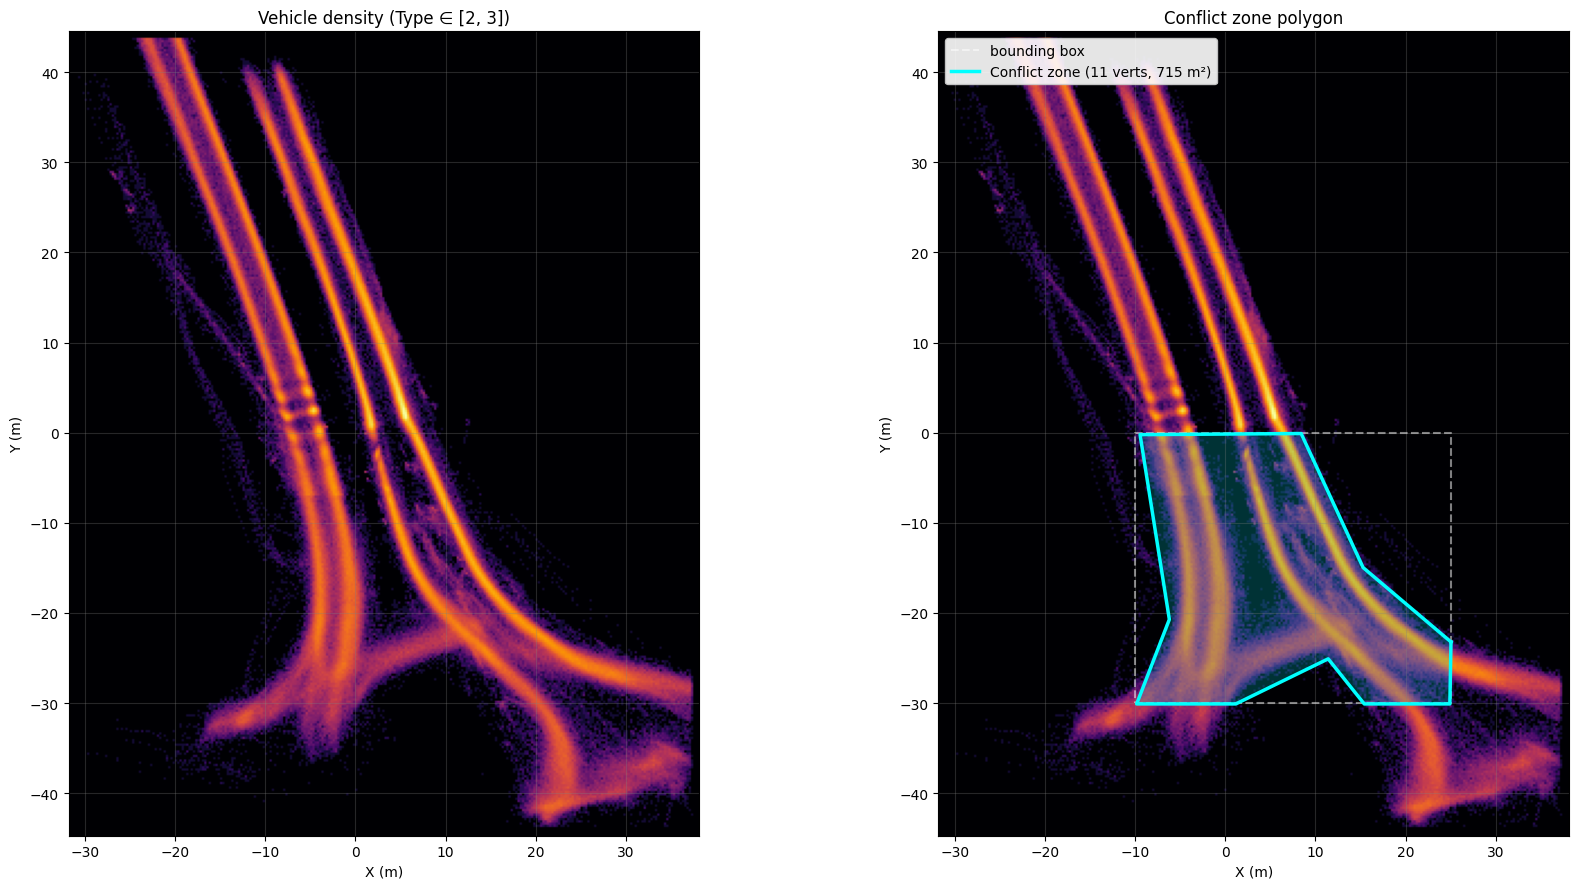

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax in axes:
    ax.imshow(np.log1p(H.T),
              extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
              origin='lower', cmap='inferno', aspect='equal')
    ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
    ax.grid(True, color='gray', alpha=0.3)

axes[0].set_title(f'Vehicle density (Type ∈ {sorted(VEHICLE_TYPES)})')

axes[1].plot([BBOX_X[0], BBOX_X[1], BBOX_X[1], BBOX_X[0], BBOX_X[0]],
             [BBOX_Y[0], BBOX_Y[0], BBOX_Y[1], BBOX_Y[1], BBOX_Y[0]],
             '--', color='white', alpha=0.5, label='bounding box')
axes[1].plot(sx, sy, '-', color='cyan', linewidth=2.5,
             label=f'Conflict zone ({len(sx)} verts, {sh_simple.area:.0f} m²)')
axes[1].fill(sx, sy, color='cyan', alpha=0.2)
axes[1].set_title('Conflict zone polygon')
axes[1].legend(loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('conflict_zone_polygon.png', dpi=110)
plt.show()

## 5. Validate

Three checks: (a) what fraction of vehicles pass through the polygon, (b) does mean speed drop inside, and (c) is the typical transit time plausible (a few seconds)?

In [6]:
# Fast point-in-polygon using matplotlib's Path (vectorised).
veh_full = df[df['Type'].isin(VEHICLE_TYPES)].copy()
path = MplPath(CONFLICT_ZONE_POLYGON)
veh_full['in_zone'] = path.contains_points(veh_full[['X', 'Y']].to_numpy())

print(f'Vehicle points in conflict zone: {veh_full["in_zone"].sum():,} ({veh_full["in_zone"].mean()*100:.1f}%)')
print(f'\nSpeed (km/h) inside vs outside:')
print(veh_full.groupby('in_zone')['Speed'].describe()[['count', 'mean', '50%', 'std']].round(2))

n_enter = veh_full[veh_full['in_zone']]['ID'].nunique()
n_total = veh_full['ID'].nunique()
print(f'\nUnique vehicles entering: {n_enter:,} / {n_total:,} = {n_enter/n_total*100:.1f}%')

transit = veh_full.groupby('ID')['in_zone'].sum() * 0.25  # ~4 Hz sampling, ≈ 0.25 s/point
transit = transit[transit > 0]
print(f'\nApprox. transit time (s) for vehicles that enter:')
print(transit.describe(percentiles=[.05, .5, .95]).round(2))

Vehicle points in conflict zone: 612,033 (42.6%)

Speed (km/h) inside vs outside:
            count   mean    50%   std
in_zone                              
False    825063.0  29.38  30.84  13.1
True     612033.0  20.38  20.15   8.7

Unique vehicles entering: 43,514 / 56,133 = 77.5%

Approx. transit time (s) for vehicles that enter:
count    43514.00
mean         3.52
std          2.13
min          0.25
5%           0.50
50%          3.50
95%          7.25
max         20.75
Name: in_zone, dtype: float64


## 6. Save polygon for downstream use

In [7]:
with open('conflict_zone_polygon.py', 'w') as f:
    f.write('# Auto-generated by 01_define_conflict_zone.ipynb\n')
    f.write('# Polygon vertices (X, Y) in metres, in the local coordinate frame.\n\n')
    f.write('CONFLICT_ZONE_POLYGON = [\n')
    for x, y in CONFLICT_ZONE_POLYGON:
        f.write(f'    ({x:.3f}, {y:.3f}),\n')
    f.write(']\n')

print('Saved conflict_zone_polygon.py')
print('Saved conflict_zone_polygon.png')

Saved conflict_zone_polygon.py
Saved conflict_zone_polygon.png
